In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# add code directory to path
import sys
import os
sys.path.append(os.path.join(os.path.abspath(''), 'code'))

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
FUNCLIB_PATH_TEMPLATE = "/home/labs/fleishman/omripo/FuncLib/PTE_FS_Dist_{n}_12Feb/FilterScan/scores/res{res_num}A_score_full.log"
N = 25
RESIDUES = [106, 132, 254, 257, 271, 303, 306, 317]
RES_MAP = {106: "I", 132: "F", 254: "H", 257: "H", 271: "L", 303: "L", 306: "F", 317: "M"}
COLS = ["res_num", "residue", "mutation", "score"]

In [17]:
dfs_dict = {}
for res in RESIDUES:
    df_list = []
    for n in range(N):
        path = FUNCLIB_PATH_TEMPLATE.format(n=n, res_num=res)
        df = pd.read_csv(path, sep="\t", names=COLS)
        df_list.append(df)
    df = pd.concat(df_list)
    dfs_dict[res] = df

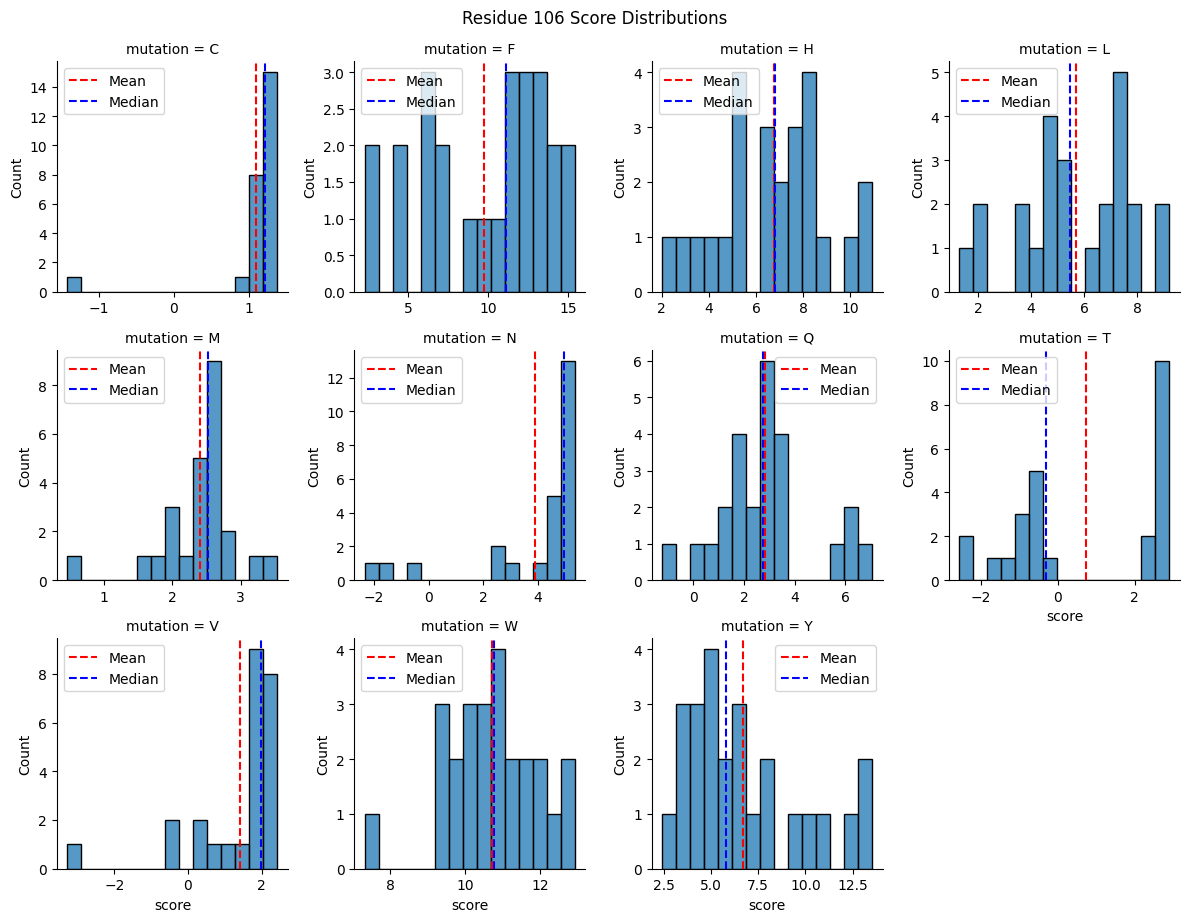

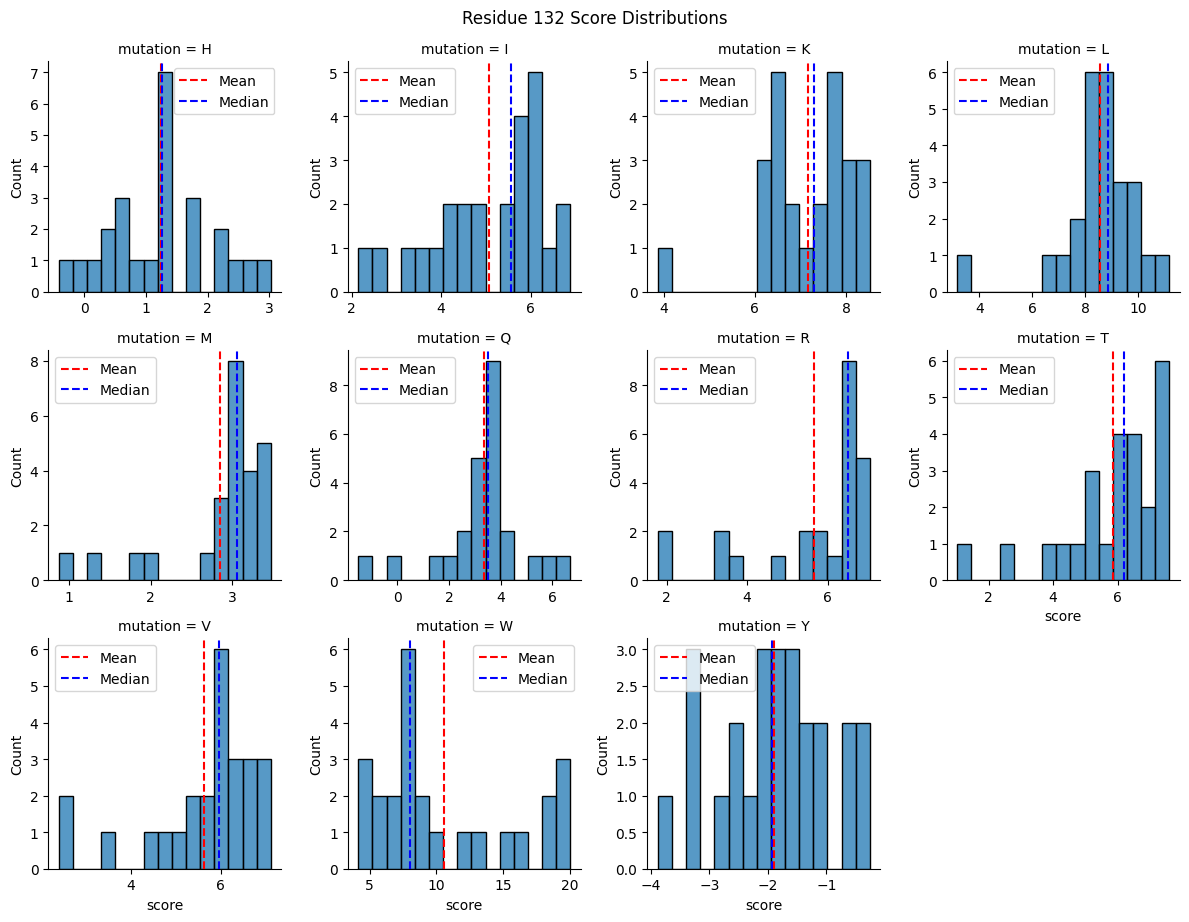

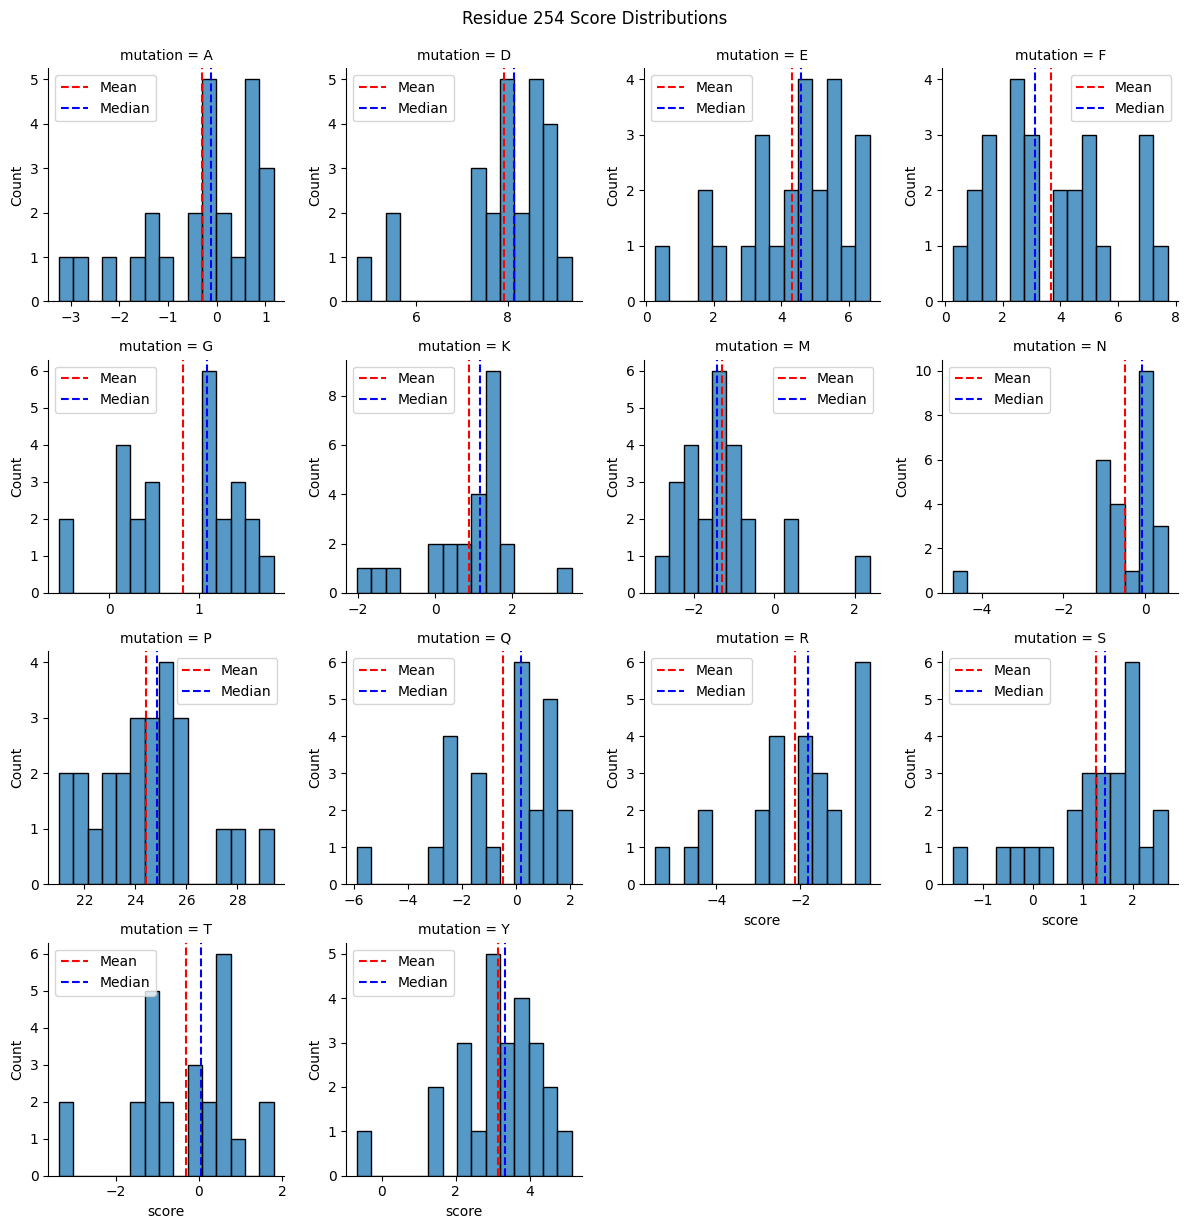

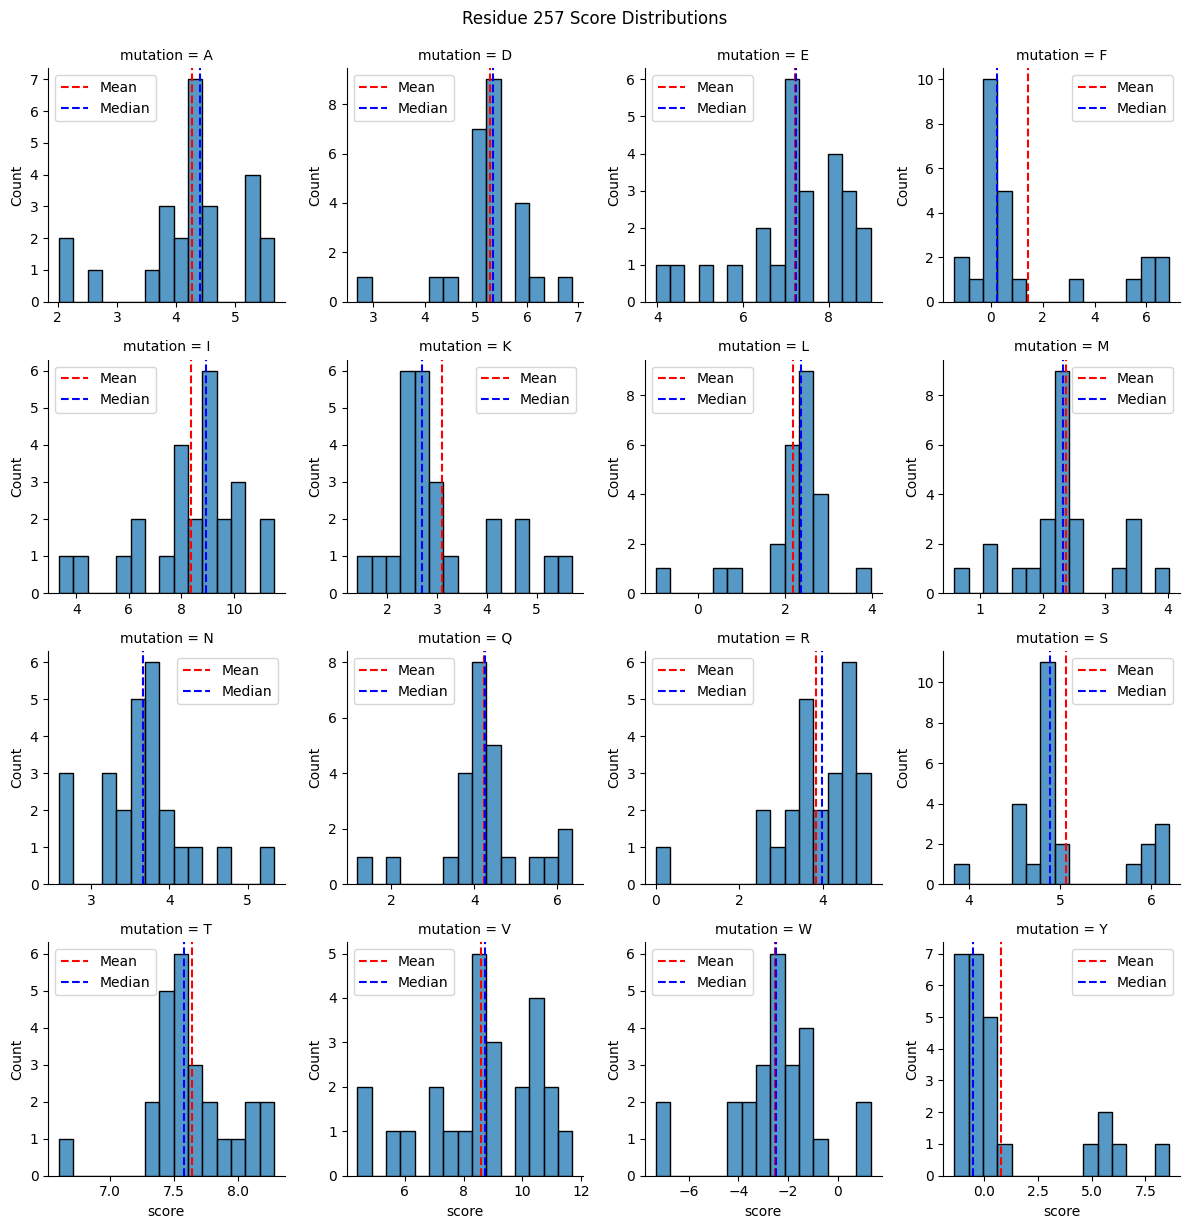

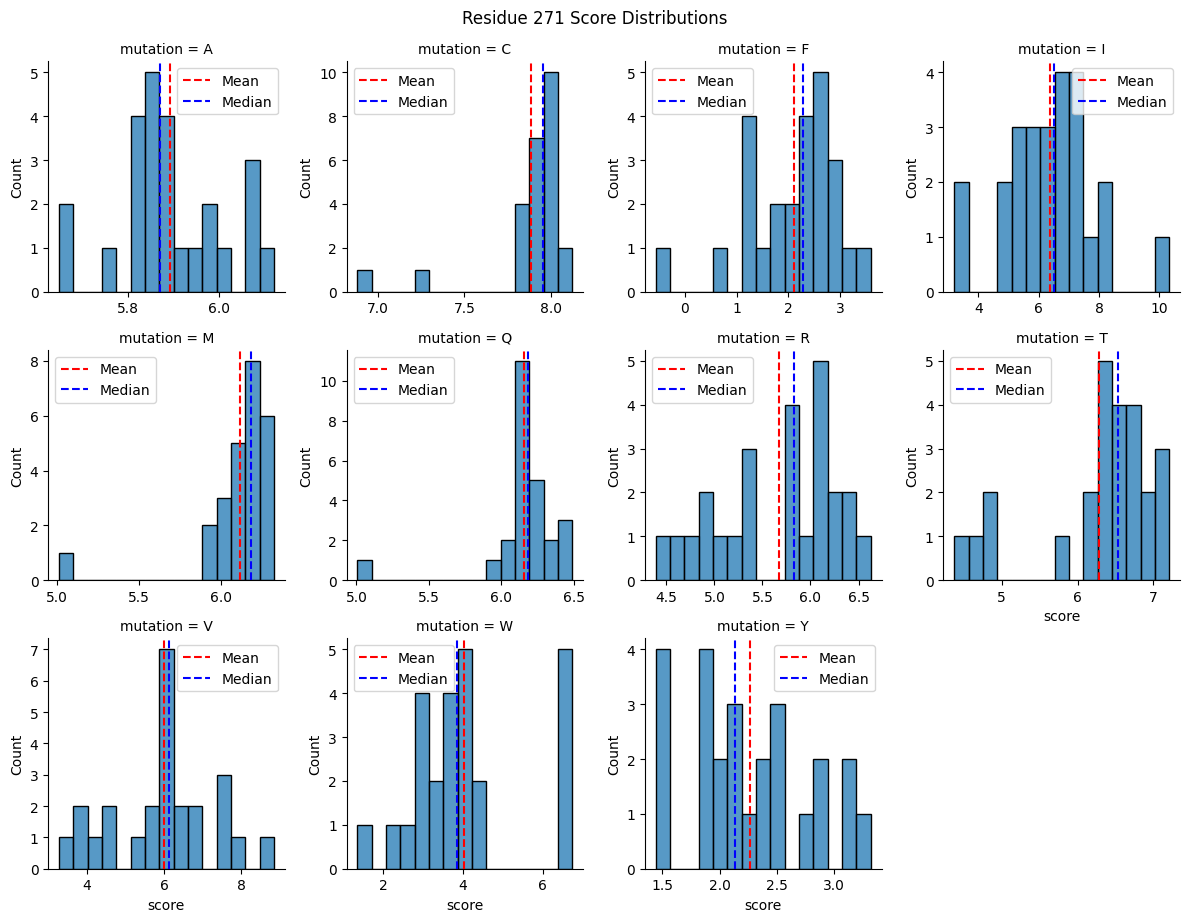

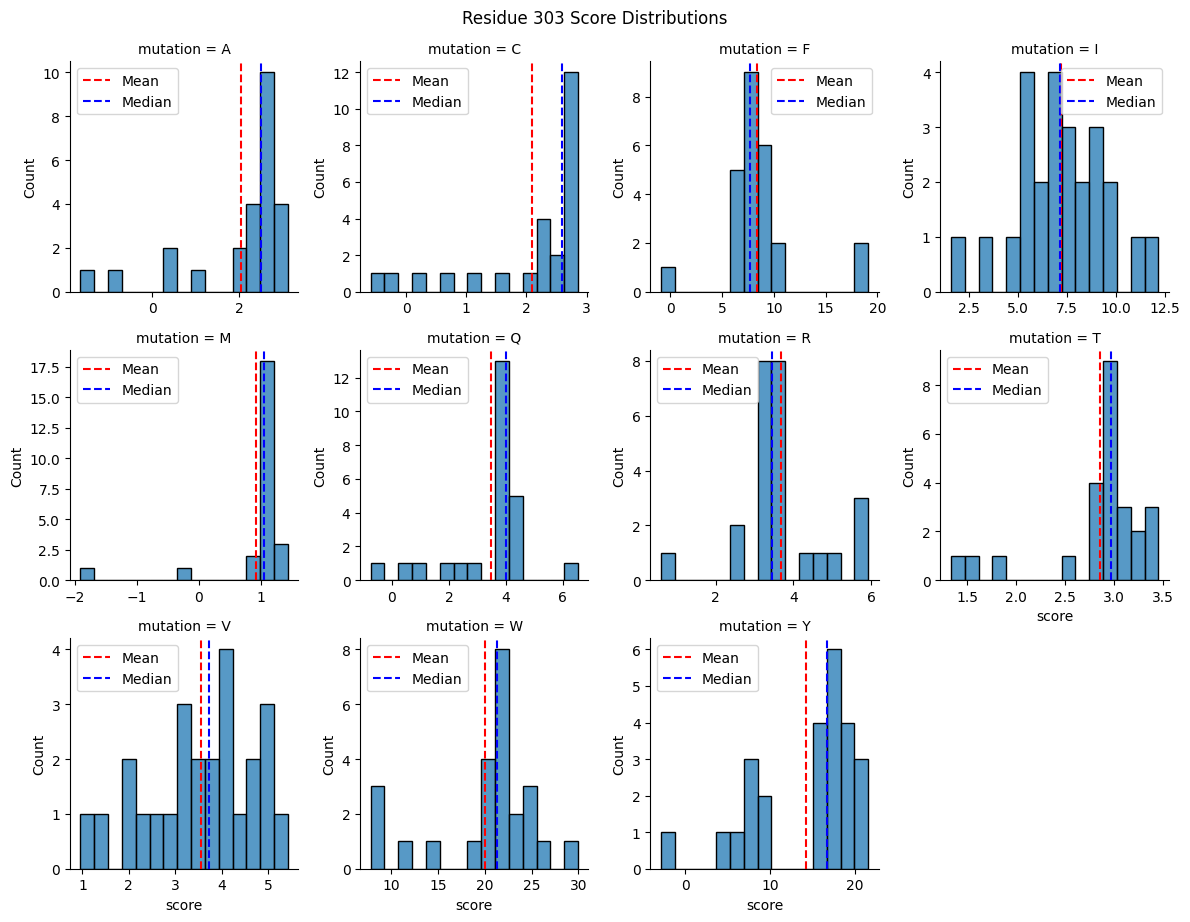

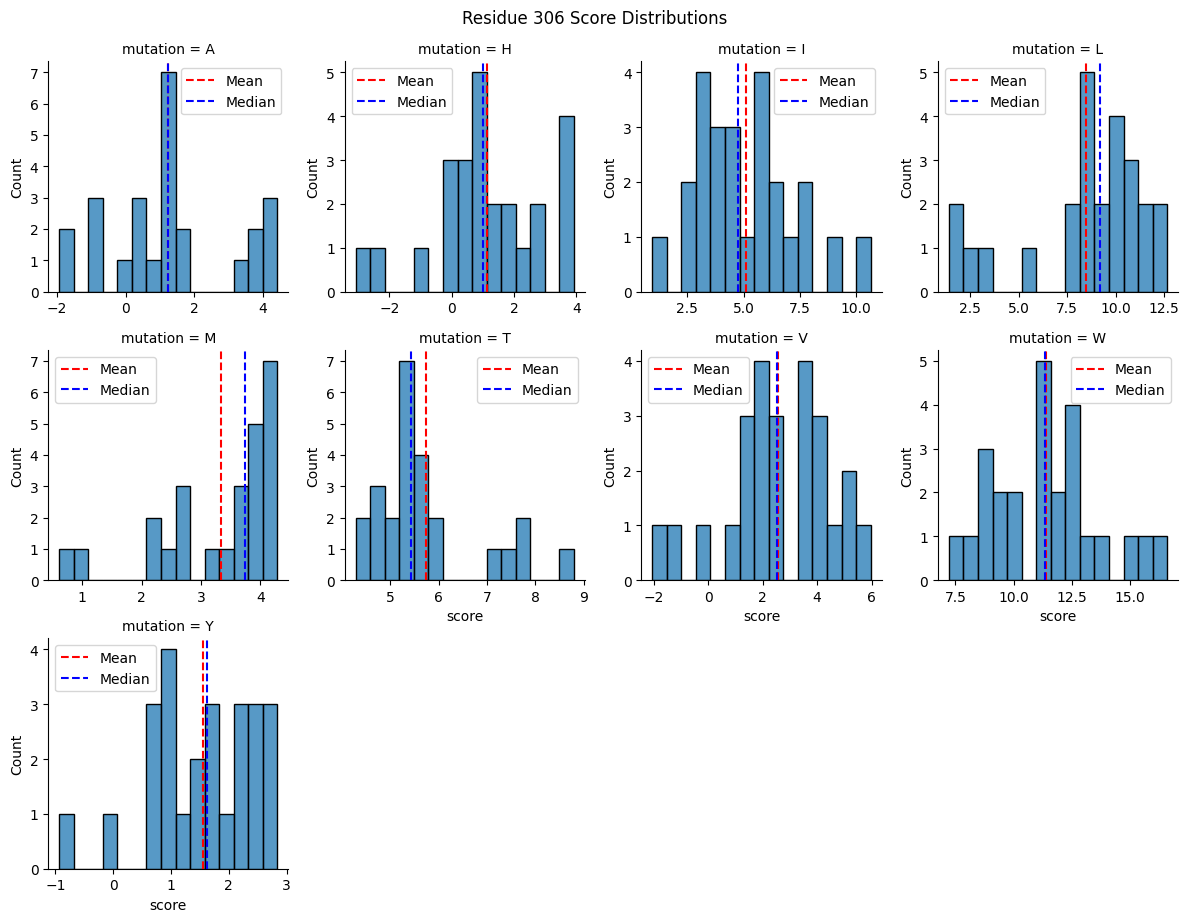

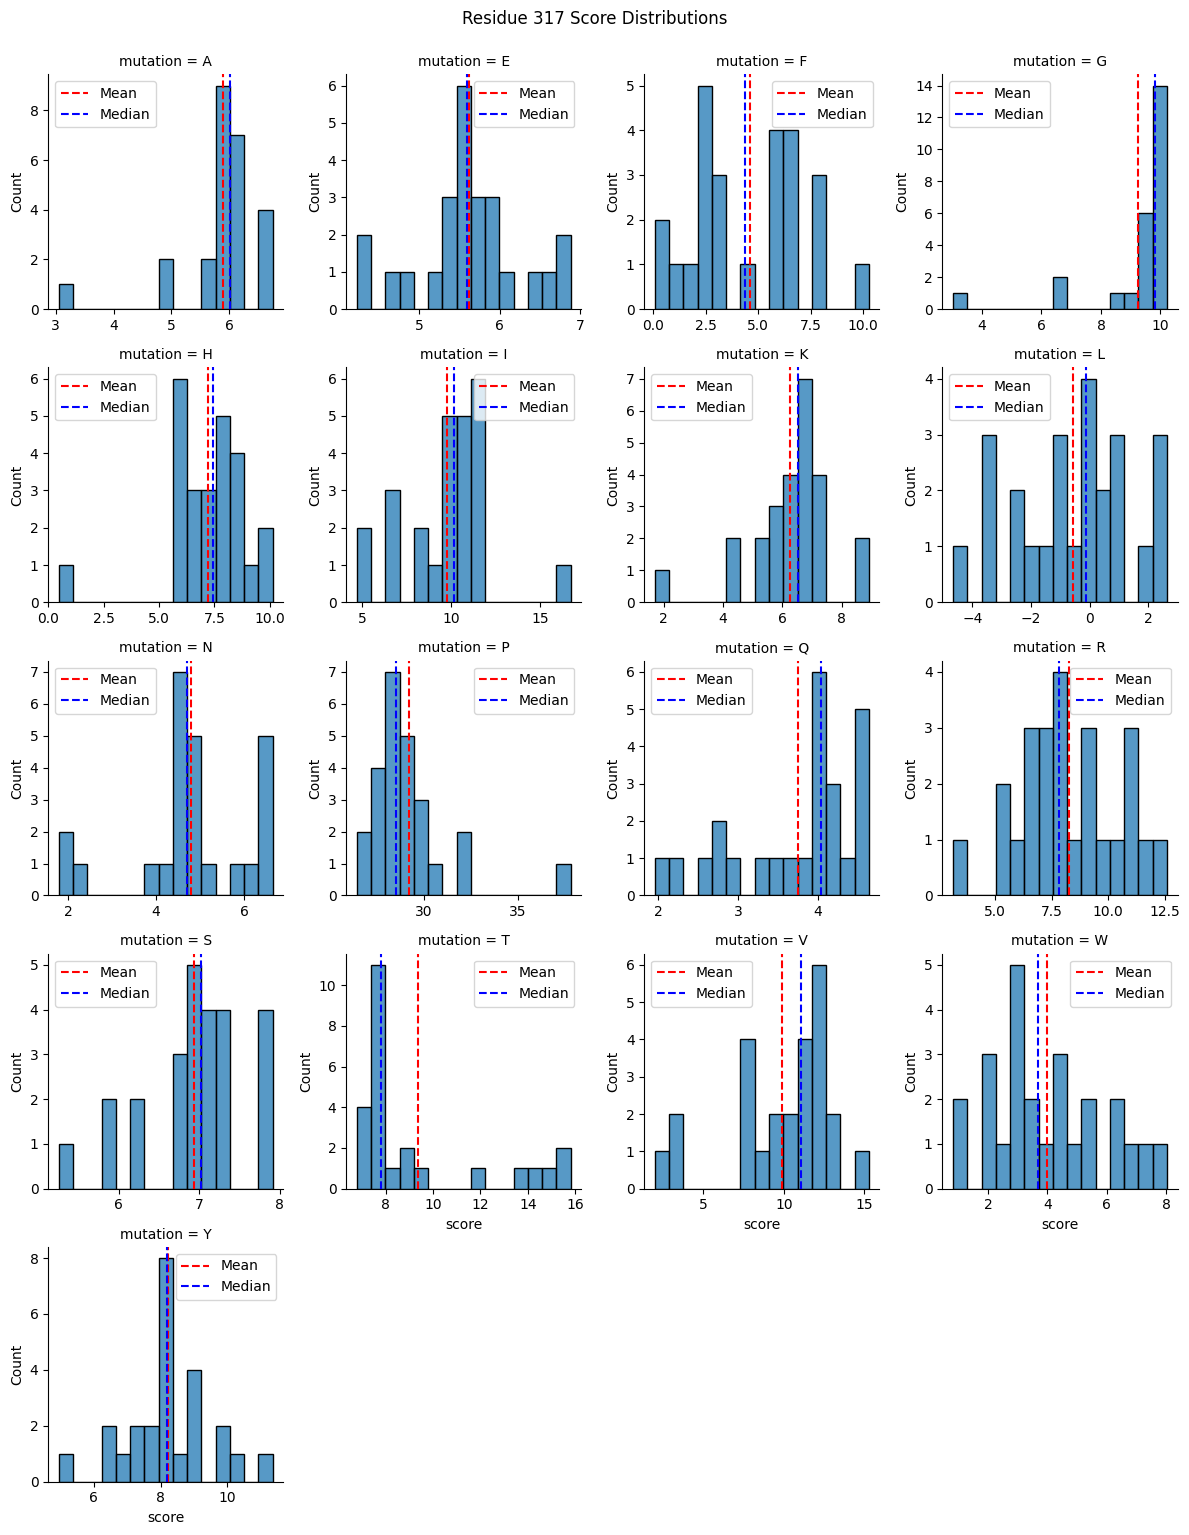

In [25]:
for res, df in dfs_dict.items():
    # for each residue, plot a panel of histograms of scores for each mutation
    # each mutations should be a different plot in the panel
    # remove self mutations (where residue is mutated to itself)
    df_for_plot = df[df["mutation"] != df["residue"]]
    g = sns.FacetGrid(df_for_plot, col="mutation", col_wrap=4, sharex=False, sharey=False)
    g.map(sns.histplot, "score", bins=15)
    # add mean and median lines to each plot
    for mutation, ax in g.axes_dict.items():
        mutation_df = df_for_plot[df_for_plot["mutation"] == mutation]
        mean_score = mutation_df["score"].mean()
        median_score = mutation_df["score"].median()
        ax.axvline(mean_score, color="red", linestyle="--", label="Mean")
        ax.axvline(median_score, color="blue", linestyle="--", label="Median")
        ax.legend()
    g.figure.suptitle(f"Residue {res} Score Distributions", y=1.02)
    plt.show() 

In [39]:
# for each residue, create a df of the mean and median scores for each mutation, and save it as a csv
summary_dfs = {}
for res, df in dfs_dict.items():
    temp_df = df.groupby("mutation")["score"].agg(["mean", "median"]).reset_index()
    summary_dfs[res] = temp_df

In [40]:
SCORE_LOG_FILE_TEMPLATE = "/home/labs/fleishman/omripo/Projects/adaptive_learning/results/PTE/filterscan/scores/res{res_num}A_score_full_median.log"
OFFSET = 34
for res, summary_df in summary_dfs.items():
    summary_df["res_num"] = res
    summary_df["residue"] = RES_MAP[res]
    summary_df["mutation"] = summary_df["mutation"].str.strip()
    summary_df = summary_df[["res_num", "residue", "mutation", "median"]]
    summary_df.to_csv(SCORE_LOG_FILE_TEMPLATE.format(res_num=res), sep="\t", index=False, header=False)

In [41]:
# create resfiles for all residues in increments of 0.5, from 0 to 6. keep only mutations with median scores below the threshold for each resfile.
RESFILE_TEMPLATE = "/home/labs/fleishman/omripo/Projects/adaptive_learning/results/PTE/filterscan/resfiles/designable_aa_resfile_median.{threshold}"
for threshold in [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6]:
    with open(RESFILE_TEMPLATE.format(threshold=threshold), "w") as f:
        f.write("nataa\n")
        f.write("start\n")
        for res, summary_df in summary_dfs.items():
            res_num = res
            residue = RES_MAP[res]
            temp_df = summary_df[summary_df["median"] <= threshold]
            allowed_mutations = temp_df["mutation"].tolist()
            allowed_mutations_str = "".join(allowed_mutations)
            f.write(f"{res_num}\tA\tPIKAA\t{allowed_mutations_str}\n")